<a href="https://colab.research.google.com/github/sn0wsally/self-study-Spatial-Transcriptomics/blob/main/clinical_validation/Clustering_to_Clinical_Validation_sample2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scanpy squidpy leidenalg matplotlib pandas

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dask[array,dataframe] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━

In [2]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [4]:
print("🚀 1. Breast cancer ST data loading... (10x Genomics Visium)")
# Breast Cancer data download (powered by Scanpy built-in function)
adata = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_2")
adata.var_names_make_unique()

🚀 1. Breast cancer ST data loading... (10x Genomics Visium)


  0%|          | 0.00/9.87M [00:00<?, ?B/s]

  0%|          | 0.00/27.6M [00:00<?, ?B/s]

In [5]:
# --- Data Preprocessing ---
print("⚙️ 2. Data Preprocessing & Normalization...")
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

⚙️ 2. Data Preprocessing & Normalization...


In [6]:
# --- Dimension reduction & Clustering ---
print("🧮 3. Clustering -> Zonation...")
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# clustering only with large blocks (tumor core, immune cell region etc.)
sc.tl.leiden(adata, resolution=0.5)

🧮 3. Clustering -> Zonation...


In [7]:
# --- TME (tumor microenvironment) & DGE (distinctive gene expression) analysis ---
print("🔬 4. TME & DGE analysis...")
# marker gene extraction by t-test
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

🔬 4. TME & DGE analysis...


🎨 5. Result visualization & Saving ...


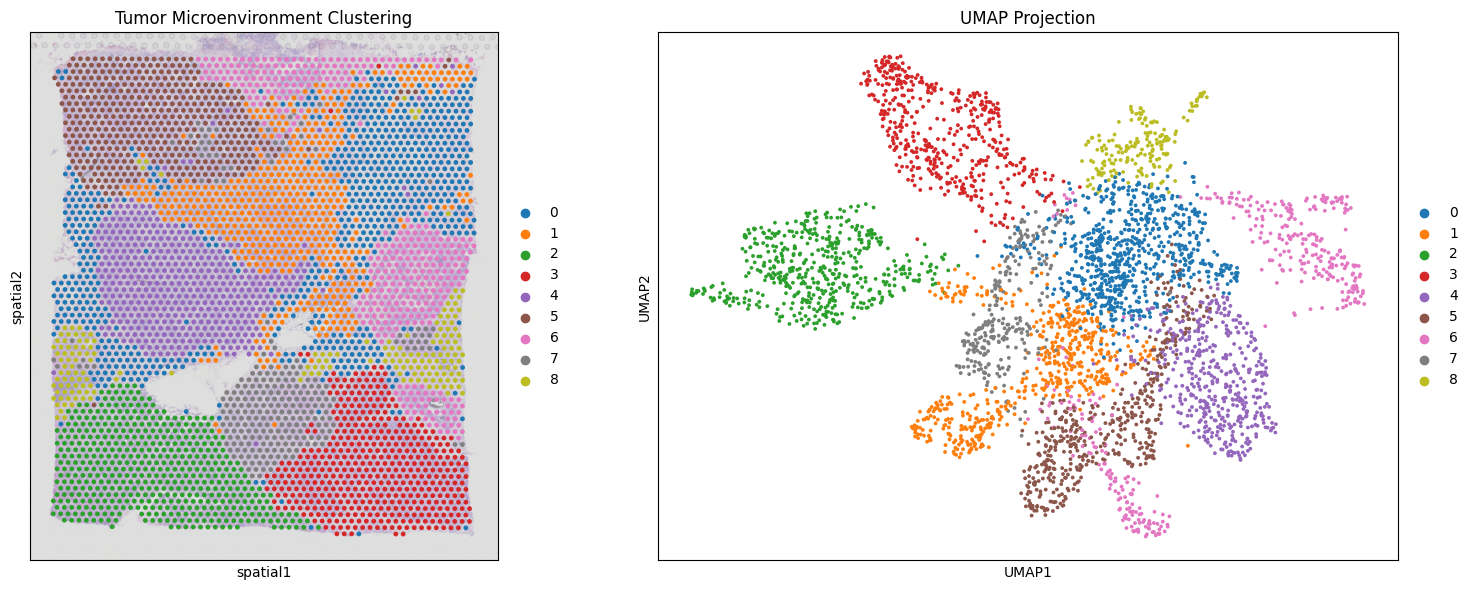

In [8]:
# --- Visualization ---
print("🎨 5. Result visualization & Saving ...")
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# [Figure 1] TME region mapping
sc.pl.spatial(
    adata,
    color="leiden",
    ax=axs[0],
    title="Tumor Microenvironment Clustering",
    alpha_img=0.5,
    show=False
)

# [Figure 2] UMAP
sc.pl.umap(adata, color="leiden", ax=axs[1], title="UMAP Projection", show=False)
plt.tight_layout()
plt.savefig("03_breast_cancer_tme_clusters.png", dpi=300)

In [9]:
print(adata.var_names.tolist())

['AL627309.1', 'AP006222.2', 'LINC01409', 'LINC01128', 'LINC00115', 'FAM41C', 'LINC02593', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'AL645608.7', 'HES4', 'ISG15', 'AGRN', 'RNF223', 'C1orf159', 'LINC01342', 'AL390719.2', 'TNFRSF18', 'TNFRSF4', 'SDF4', 'B3GALT6', 'C1QTNF12', 'UBE2J2', 'SCNN1D', 'ACAP3', 'PUSL1', 'INTS11', 'CPTP', 'TAS1R3', 'DVL1', 'MXRA8', 'AURKAIP1', 'CCNL2', 'MRPL20-AS1', 'MRPL20', 'AL391244.2', 'ANKRD65', 'LINC01770', 'VWA1', 'ATAD3C', 'ATAD3B', 'ATAD3A', 'TMEM240', 'SSU72', 'AL645728.1', 'FNDC10', 'AL691432.4', 'AL691432.2', 'MIB2', 'MMP23B', 'CDK11B', 'FO704657.1', 'SLC35E2B', 'CDK11A', 'SLC35E2A', 'NADK', 'GNB1', 'AL109917.1', 'CALML6', 'TMEM52', 'GABRD', 'PRKCZ', 'PRKCZ-AS1', 'FAAP20', 'AL590822.1', 'SKI', 'AL590822.3', 'MORN1', 'AL589739.1', 'AL513477.2', 'RER1', 'PEX10', 'PLCH2', 'PANK4', 'HES5', 'AL139246.5', 'TNFRSF14-AS1', 'TNFRSF14', 'AL139246.3', 'PRXL2B', 'MMEL1', 'TTC34', 'PRDM16-DT', 'PRDM16', 'ARHGEF16', 'AL512413.1', 'MEGF6', 'AL513320.1', 'TPR

categories: 0, 1, 2, etc.
var_group_labels: Tumor Cells, T Cells (General), CD4+ T Cells, etc.


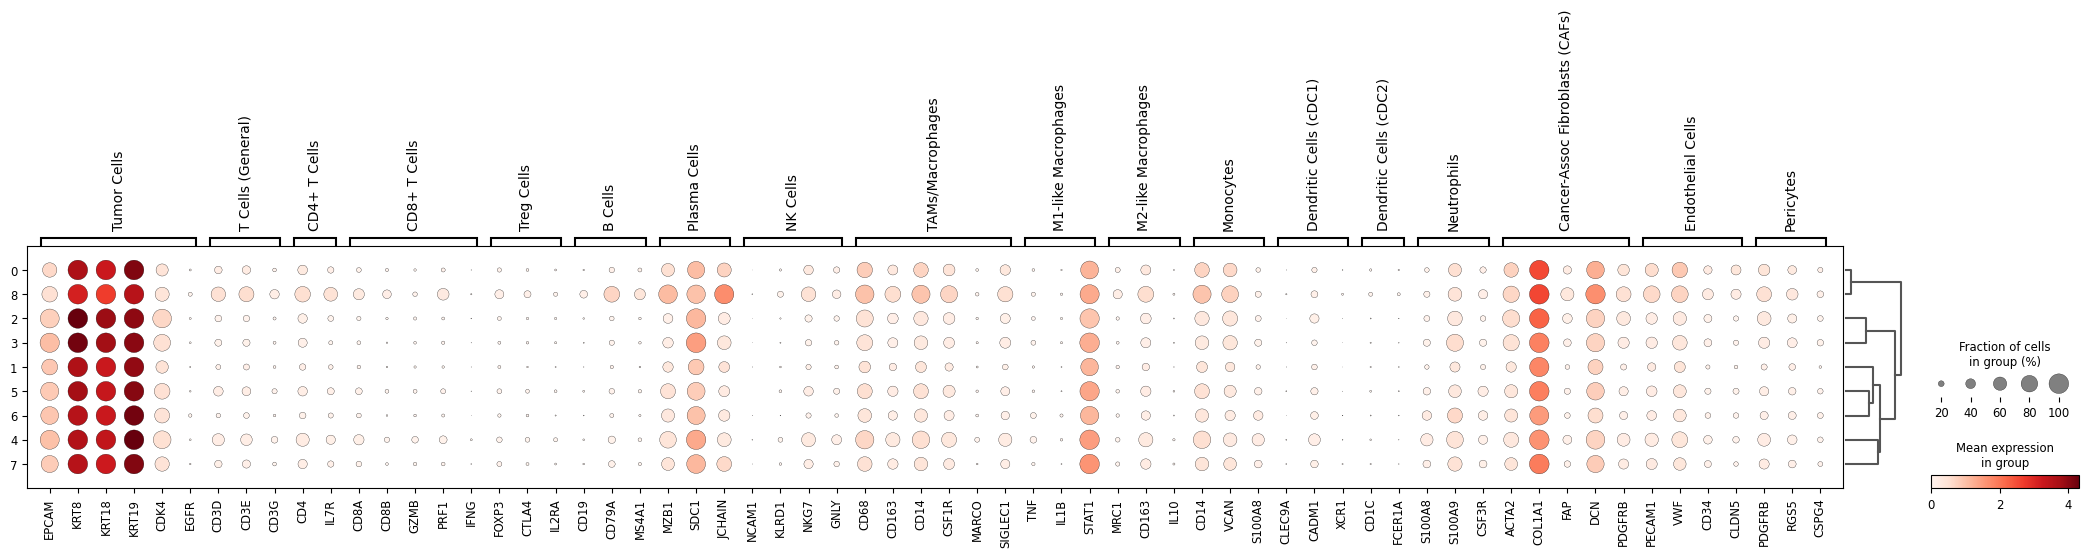

In [10]:
# [Figure 3] Dotplot for marker gene expression amount by each cluster
tme_markers = {
"Tumor Cells": ["EPCAM", "KRT8", "KRT18", "KRT19", "CDK4", "EGFR"],
"T Cells (General)": ["CD3D", "CD3E", "CD3G"],
"CD4+ T Cells": ["CD4", "IL7R"],
"CD8+ T Cells": ["CD8A", "CD8B", "GZMB", "PRF1", "IFNG"],
"Treg Cells": ["FOXP3", "CTLA4", "IL2RA"],
"B Cells": ["CD19", "CD79A", "MS4A1"],
"Plasma Cells": ["MZB1", "SDC1", "JCHAIN"],
"NK Cells": ["NCAM1", "KLRD1", "NKG7", "GNLY"],
"TAMs/Macrophages": ["CD68", "CD163", "CD14", "CSF1R", "MARCO", "SIGLEC1"],
"M1-like Macrophages": ["NOS2", "TNF", "IL1B", "STAT1"],
"M2-like Macrophages": ["MRC1", "ARG1", "CD163", "IL10"],
"Monocytes": ["CD14", "VCAN", "S100A8"],
"Dendritic Cells (cDC1)": ["CLEC9A", "CADM1", "XCR1"],
"Dendritic Cells (cDC2)": ["CD1C", "FCER1A"],
"Neutrophils": ["S100A8", "S100A9", "CSF3R", "ELANE"],
"Cancer-Assoc Fibroblasts (CAFs)": ["ACTA2", "COL1A1", "FAP", "DCN", "PDGFRB"],
"Endothelial Cells": ["PECAM1", "VWF", "CD34", "CLDN5"],
"Pericytes": ["PDGFRB", "RGS5", "CSPG4"]
}

# Filter tme_markers to include only genes present in adata.var_names
filtered_tme_markers = {}
for cell_type, genes in tme_markers.items():
    filtered_genes = [gene for gene in genes if gene in adata.var_names]
    if filtered_genes:
        filtered_tme_markers[cell_type] = filtered_genes

sc.pl.dotplot(adata, filtered_tme_markers, "leiden", dendrogram=True)